In [2]:
import json

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sb

from lcdb.db.processors._traceback_extractor import TracebackExtractor
from lcdb.db._results import ResultSet
from lcdb.analysis.views._util import get_cli_test_command

In [3]:
expected_datasets = [3, 12, 23, 31, 54, 181, 188, 1049, 1067, 1111, 1169, 1457, 1461, 1464, 1468, 1475, 1486, 1487, 1489, 1494, 1515, 1590, 1596, 4134, 4135, 4534, 4538, 4541, 23517, 40498, 40668, 40670, 40685, 40701, 40900, 40975, 40978, 40981, 40982, 40983, 40984, 40996, 41027, 41138, 41142, 41143, 41144, 41145, 41146, 41147, 41150, 41156, 41157, 41158, 41159, 41161, 41162, 41163, 41164, 41165, 41166, 41167, 41168, 41169, 42732, 42733, 42734, 42742, 42746, 42769, 43072]

In [10]:
rs = ResultSet.concat([
    ResultSet.read_jsonl(f"../surf/snellius/data/{k}.jsonl")
    for k in [
        "lcdb.workflow.sklearn.KNNWorkflow",
        "lcdb.workflow.sklearn.LibLinearWorkflow",
        "lcdb.workflow.sklearn.LibSVMWorkflow",
        "lcdb.workflow.sklearn.TreesEnsembleWorkflow",
        "lcdb.workflow.xgboost.XGBoostWorkflow",
        "lcdb.workflow.keras.DenseNNWorkflow"
    ]
])
print(rs.num_rows)

154076


In [11]:
print(sorted(rs.datasets))

[3, 12, 23, 31, 54, 181, 188, 1049, 1067, 1111, 1169, 1457, 1461, 1464, 1468, 1475, 1486, 1487, 1489, 1494, 1515, 1590, 1596, 4134, 4135, 4534, 4538, 4541, 23517, 40498, 40668, 40670, 40685, 40701, 40900, 40975, 40978, 40981, 40982, 40983, 40984, 40996, 41027, 41138, 41142, 41143, 41144, 41145, 41146, 41147, 41150, 41156, 41157, 41158, 41159, 41161, 41162, 41163, 41164, 41165, 41166, 41167, 41168, 41169, 42732, 42733, 42734, 42742, 42746, 42769]


23
	Job "Traceback (most recent call last):
  File "/gpfs/home2/cyan/lcdb/publications/2023-neurips/lcdb/builder/_base.py", line 390, in build_curves
    self.fit_workflow_on_current_anchor()
  File "/gpfs/home2/cyan/lcdb/publications/2023-neurips/lcdb/builder/_base.py", line 473, in fit_workflow_on_current_anchor
    self.workflow.fit(
  File "/gpfs/home2/cyan/lcdb/publications/2023-neurips/lcdb/builder/utils.py", line 127, in terminate_on_timeout
    return results.get(timeout)
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/cyan/miniconda3/envs/lcdbgpu/lib/python3.11/multiprocessing/pool.py", line 774, in get
    raise self._value
  File "/home/cyan/miniconda3/envs/lcdbgpu/lib/python3.11/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
                    ^^^^^^^^^^^^^^^^^^^
  File "/gpfs/home2/cyan/lcdb/publications/2023-neurips/lcdb/workflow/_base_workflow.py", line 105, in fit
    self._fit(
  File "/gpfs/home2/cyan/lcdb/publications/2023-neuri

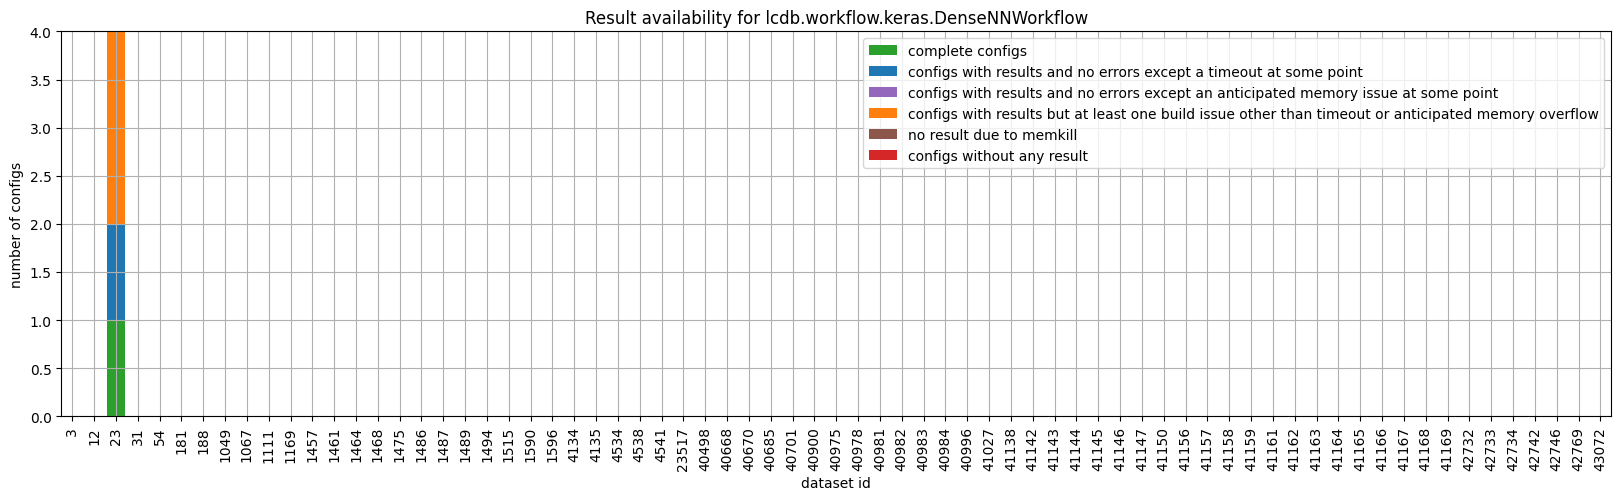

In [18]:
traceback_extractor = TracebackExtractor()

for workflow, rs_workflow in rs.group_by_workflow():
    if "keras" not in workflow:
        continue

    fig, ax = plt.subplots(figsize=(20, 5))

    status_data = []
    datasets = []

    max_num_results = 0
    for openmlid in expected_datasets:
        
        rs_dataset = rs_workflow.filter_datasets(openmlid)

        # first separate those that have no results at all
        rs_no_results, rs_with_results = rs_dataset.split(lambda r: r['payload'] < 1000)
        
        # within the group of no results, separate those with a memory error from the others
        rs_memory_killed, rs_other_kill = rs_no_results.split(lambda r: "error" in r and r["error"] == "F_memory_limit_exceeded")
        num_memory_killed = rs_memory_killed.num_rows
        num_no_results_other_reason = rs_other_kill.num_rows
        if False and num_no_results_other_reason > 0:
            print(openmlid)
            for row in rs_other_kill:
                print("\tJob", row["experiment_metadata"]["job_id"], row["error"])

        # now check those that have no build issues from those that have
        rs_ok, rs_with_issues = rs_with_results.split(lambda r: 'build_issues' not in r or r['build_issues'] is None)
        num_ok = rs_ok.num_rows

        # separate those where the only build issue is a timeout
        rs_with_only_timeouts, rs_with_other_issues_than_timeouts = rs_with_issues.split(lambda r: all(bi["message"] == "timeout" for bi in r["traceback_summary"]))
        num_with_data_and_timeout_being_the_only_issue = rs_with_only_timeouts.num_rows
        
        # separate those where the only build issue is an anticipated memory overflow
        rs_with_anticipated_memory_overflow, rs_with_other_issues = rs_with_other_issues_than_timeouts.split(lambda r: all(bi["message"] == "anticipated memory overflow" for bi in r["traceback_summary"]))
        num_with_anticipated_memory_overflow = rs_with_anticipated_memory_overflow.num_rows
        num_with_other_build_issues = rs_with_other_issues.num_rows

        if num_with_other_build_issues > 0:
            print(openmlid)
            for row in rs_with_other_issues:
                print("\tJob", list(json.loads(row["build_issues"]).values())[0])
        
        datasets.append(openmlid)
        status_data.append([num_ok, num_with_data_and_timeout_being_the_only_issue, num_with_anticipated_memory_overflow, num_with_other_build_issues, num_memory_killed, num_no_results_other_reason])

    status_data = np.array(status_data)
    n_rows, n_cols = status_data.shape
    x = 0.5 + np.arange(n_rows)  # one bar per row

    bottom = np.zeros(n_rows)
    for j, label, color in zip(
        range(n_cols),
        ["complete configs", "configs with results and no errors except a timeout at some point", "configs with results and no errors except an anticipated memory issue at some point", "configs with results but at least one build issue other than timeout or anticipated memory overflow", "no result due to memkill", "configs without any result"],
        ["C2", "C0", "C4", "C1", "C5", "C3"]
    ):
        ax.bar(x, status_data[:, j], bottom=bottom, label=label, color=color)
        bottom += status_data[:, j]
    
    ax.set_xticks(0.5 + np.arange(len(datasets)))
    ax.set_xlim([0, len(datasets)])
    ax.set_xticklabels(datasets, rotation=90)
    ax.set_xlabel("dataset id")
    ax.set_ylabel("number of configs")
    ax.set_title(f"Result availability for {workflow}")
    ax.grid()
    #ax.set_ylim(np.arange(0, len()))
    ax.legend()
    plt.show()

In [3]:
rs_ds = rs.filter_datasets(1457)
rs_ds.to_pandas()

NameError: name 'rs' is not defined

In [4]:
print(sorted([8, 3, 7, 1, 6, 13, 5, 0, 21, 11, 10, 9, 14, 12, 4, 15, 17, 19, 0, 21, 18, 23, 24, 26, 16, 27, 25, 22, 28, 2, 30, 29, 32, 31, 33, 35, 40, 34, 39, 41, 20, 38, 36, 37, 42, 46, 47, 43, 49, 59, 44, 45, 50, 53, 55, 48, 54, 56, 58, 51, 52, 57, 49, 59, 56, 58, 62, 68, 66, 64, 60, 70, 61, 69]))

[0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 49, 50, 51, 52, 53, 54, 55, 56, 56, 57, 58, 58, 59, 59, 60, 61, 62, 64, 66, 68, 69, 70]
